# Check in side data

In [5]:
import os
import pandas as pd
import pyedflib
import numpy as np
import IPython.display as ipd
import os, glob
import pandas as pd
import pyedflib
import numpy as np
import IPython.display as ipd


# =====================
# Config
# =====================
EDF_DIR = r"C:\V89\data_test\EDF"
CSV_PATH = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"

In [6]:
df = pd.read_csv(CSV_PATH)

# pick one Snore event
snore_row = df[df["type"]=="Snore"].iloc[0]
# pick one Apnea event
apnea_row = df[df["type"].isin(["Hypopnea","MixedApnea","Osa","CentralApnea"])].iloc[0]

print("Snore row:\n", snore_row)
print("Apnea row:\n", apnea_row)

Snore row:
 patient_id                                1010
event_id                                     3
family                                   Nasal
type                                     Snore
start_sec                                 40.0
duration_sec                               6.0
end_sec                                   46.0
segment_index                                0
segment_local_start_sec                   40.0
recording_start_iso        2019-05-03T23:06:21
Name: 0, dtype: object
Apnea row:
 patient_id                                1010
event_id                                    36
family                             Respiratory
type                                  Hypopnea
start_sec                                865.0
duration_sec                              12.0
end_sec                                  877.0
segment_index                                0
segment_local_start_sec                  865.0
recording_start_iso        2019-05-03T23:06:21
Name: 3, dtyp

In [4]:
# =====================
# Test exported audio with trained model
# =====================
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
import glob
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def test_exported_audio():
    """Test the exported audio segments with the trained Wav2Vec2 model"""
    
    # =====================
    # CONFIG
    # =====================
    AUDIO_DIR = r"C:\V89\export_mic_events_pyedf"  # Directory with exported audio
    MODEL_DIR = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_best"
    TARGET_SR = 16000
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Check if audio directory exists
    if not os.path.exists(AUDIO_DIR):
        print(f"❌ Audio directory not found: {AUDIO_DIR}")
        print("Please run the export function first!")
        return
    
    # =====================
    # Load trained model
    # =====================
    try:
        processor = Wav2Vec2Processor.from_pretrained(MODEL_DIR)
        model = Wav2Vec2ForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
        model.eval()
        print(f"✅ Loaded model from: {MODEL_DIR}")
    except Exception as e:
        print(f"❌ Failed to load model: {e}")
        return
    
    # =====================
    # Get all audio files
    # =====================
    audio_files = glob.glob(os.path.join(AUDIO_DIR, "*.wav"))
    print(f"📂 Found {len(audio_files)} audio files")
    
    if len(audio_files) == 0:
        print("❌ No audio files found!")
        return
    
    # =====================
    # Process each audio file
    # =====================
    results = []
    
    for audio_path in audio_files:
        try:
            # Extract info from filename
            filename = os.path.basename(audio_path)
            # Format: pid{pid}_eid{eid}_{label}_{start}s.wav
            parts = filename.replace('.wav', '').split('_')
            
            # Parse filename to get true label
            true_label = None
            for part in parts:
                if part in ['Apnea', 'Snore', 'Normal']:
                    true_label = part
                    break
            
            if true_label is None:
                print(f"⚠️ Could not parse label from {filename}")
                continue
            
            # Load and preprocess audio
            waveform, sr = torchaudio.load(audio_path)
            
            # Convert to mono if needed
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
            
            # Resample if needed
            if sr != TARGET_SR:
                resampler = torchaudio.transforms.Resample(sr, TARGET_SR)
                waveform = resampler(waveform)
            
            # Convert to numpy for processor
            waveform_np = waveform.squeeze().numpy()
            
            # Process with Wav2Vec2 processor
            inputs = processor(
                waveform_np,
                sampling_rate=TARGET_SR,
                return_tensors="pt",
                padding=True,
                max_length=TARGET_SR * 10,  # Max 10 seconds
                truncation=True,
            )
            
            # Run inference
            with torch.no_grad():
                input_values = inputs.input_values.to(device)
                attention_mask = inputs.attention_mask.to(device) if inputs.attention_mask is not None else None
                
                outputs = model(input_values, attention_mask=attention_mask)
                logits = outputs.logits
                
                # Get predictions
                probs = torch.softmax(logits, dim=1)
                predicted_class = torch.argmax(logits, dim=1).item()
                confidence = probs.max().item()
                
                # Map to class names
                class_names = ['Normal/Snore', 'Apnea']  # Based on your binary classification
                predicted_label = class_names[predicted_class]
                
                # Convert true label to binary
                true_binary = 1 if true_label == 'Apnea' else 0
                
                results.append({
                    'filename': filename,
                    'true_label': true_label,
                    'true_binary': true_binary,
                    'predicted_binary': predicted_class,
                    'predicted_label': predicted_label,
                    'confidence': confidence,
                    'prob_normal': probs[0][0].item(),
                    'prob_apnea': probs[0][1].item()
                })
                
                print(f"📁 {filename}")
                print(f"   True: {true_label} | Predicted: {predicted_label} | Confidence: {confidence:.3f}")
                
        except Exception as e:
            print(f"❌ Error processing {filename}: {e}")
    
    w
        print("❌ No valid results to analyze!")
        return
    
    # Convert to DataFrame for easier analysis
    results_df = pd.DataFrame(results)
    
    # Calculate metrics
    y_true = results_df['true_binary'].values
    y_pred = results_df['predicted_binary'].values
    
    accuracy = (y_true == y_pred).mean()
    
    print(f"\n📊 Results Summary:")
    print(f"Total files processed: {len(results)}")
    print(f"Accuracy: {accuracy:.3f}")
    
    # Detailed classification report
    print(f"\n📋 Classification Report:")
    target_names = ['Normal/Snore', 'Apnea']
    print(classification_report(y_true, y_pred, target_names=target_names, digits=3))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix - Exported Audio Test')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    # Show detailed results
    print(f"\n🔍 Detailed Results:")
    print(results_df[['filename', 'true_label', 'predicted_label', 'confidence']].to_string(index=False))
    
    # Save results
    results_path = os.path.join(AUDIO_DIR, "test_results.csv")
    results_df.to_csv(results_path, index=False)
    print(f"\n💾 Results saved to: {results_path}")
    
    return results_df

# Run the test
print("🚀 Testing exported audio with trained model...")
test_results = test_exported_audio()

c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\V89\.venv\Lib\site-packages\t

🚀 Testing exported audio with trained model...
✅ Loaded model from: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_best
📂 Found 0 audio files
❌ No audio files found!
✅ Loaded model from: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V1\wav2vec2_best
📂 Found 0 audio files
❌ No audio files found!


In [6]:
# =====================
# Audio Exploration - Listen and Visualize Different Classes
# =====================
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
import librosa
import librosa.display

def explore_audio_classes():
    """Listen to and visualize different audio event types"""
    
    # Check if we have exported audio
    AUDIO_DIR = r"C:\V89\export_mic_events_pyedf"
    
    if not os.path.exists(AUDIO_DIR):
        print("❌ No exported audio found. Please run the export function first!")
        return
    
    # Get audio files by class
    audio_files = glob.glob(os.path.join(AUDIO_DIR, "*.wav"))
    
    # Group files by class
    files_by_class = {'Apnea': [], 'Snore': [], 'Normal': []}
    
    for file in audio_files:
        filename = os.path.basename(file)
        for class_name in files_by_class.keys():
            if class_name in filename:
                files_by_class[class_name].append(file)
                break
    
    print("📊 Available audio files by class:")
    for class_name, files in files_by_class.items():
        print(f"  {class_name}: {len(files)} files")
    
    # Function to analyze and display audio
    def analyze_audio(file_path, class_name):
        # Load audio
        y, sr = librosa.load(file_path, sr=16000)
        duration = len(y) / sr
        
        print(f"\n🎵 {class_name} - {os.path.basename(file_path)}")
        print(f"Duration: {duration:.2f} seconds")
        print(f"Sample rate: {sr} Hz")
        print(f"Samples: {len(y)}")
        
        # Create subplots
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))
        fig.suptitle(f'{class_name} Audio Analysis - {os.path.basename(file_path)}', fontsize=14)
        
        # 1. Waveform
        time = np.linspace(0, duration, len(y))
        axes[0].plot(time, y)
        axes[0].set_title('Waveform')
        axes[0].set_xlabel('Time (seconds)')
        axes[0].set_ylabel('Amplitude')
        axes[0].grid(True, alpha=0.3)
        
        # 2. Spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        img = librosa.display.specshow(D, x_axis='time', y_axis='hz', 
                                     sr=sr, ax=axes[1], cmap='viridis')
        axes[1].set_title('Spectrogram')
        plt.colorbar(img, ax=axes[1], format='%+2.0f dB')
        
        # 3. Mel-frequency spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.amplitude_to_db(mel_spec, ref=np.max)
        img2 = librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel',
                                      sr=sr, ax=axes[2], cmap='viridis')
        axes[2].set_title('Mel Spectrogram')
        plt.colorbar(img2, ax=axes[2], format='%+2.0f dB')
        
        plt.tight_layout()
        plt.show()
        
        # Audio statistics
        print(f"📈 Audio Statistics:")
        print(f"  Mean amplitude: {np.mean(np.abs(y)):.4f}")
        print(f"  Max amplitude: {np.max(np.abs(y)):.4f}")
        print(f"  RMS energy: {np.sqrt(np.mean(y**2)):.4f}")
        print(f"  Zero crossing rate: {np.mean(librosa.feature.zero_crossing_rate(y)):.4f}")
        
        # Play audio
        print(f"🔊 Playing audio...")
        display(ipd.Audio(y, rate=sr))
        
        return y, sr
    
    # Analyze one example from each class
    for class_name, files in files_by_class.items():
        if files:
            # Take the first file of each class
            example_file = files[0]
            analyze_audio(example_file, class_name)
            print("="*80)
    
    # Compare all classes side by side
    print("\n📊 Comparing all classes side by side...")
    
    # Check if we have any classes with files
    available_classes = [c for c in files_by_class.keys() if files_by_class[c]]
    
    if len(available_classes) == 0:
        print("❌ No audio files found to compare!")
        return
    
    fig, axes = plt.subplots(len(available_classes), 3, 
                           figsize=(15, 4*len(available_classes)))
    
    # Handle single row case
    if len(available_classes) == 1:
        axes = axes.reshape(1, -1)
    
    row = 0
    for class_name, files in files_by_class.items():
        if files:
            # Load first example
            y, sr = librosa.load(files[0], sr=16000)
            time = np.linspace(0, len(y)/sr, len(y))
            
            # Waveform
            axes[row, 0].plot(time, y)
            axes[row, 0].set_title(f'{class_name} - Waveform')
            axes[row, 0].set_xlabel('Time (s)')
            axes[row, 0].set_ylabel('Amplitude')
            axes[row, 0].grid(True, alpha=0.3)
            
            # Spectrogram
            D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
            librosa.display.specshow(D, x_axis='time', y_axis='hz', 
                                   sr=sr, ax=axes[row, 1], cmap='viridis')
            axes[row, 1].set_title(f'{class_name} - Spectrogram')
            
            # Mel spectrogram
            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            mel_spec_db = librosa.amplitude_to_db(mel_spec, ref=np.max)
            librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel',
                                   sr=sr, ax=axes[row, 2], cmap='viridis')
            axes[row, 2].set_title(f'{class_name} - Mel Spectrogram')
            
            row += 1
    
    plt.tight_layout()
    plt.show()

# Let's also add a simple function to just work with the original EDF data if no exported files exist
def quick_audio_exploration():
    """Quick audio exploration directly from EDF file"""
    print("🎵 Quick audio exploration from EDF...")
    
    EDF_PATH = r"C:\V89\data_test\EDF\00001010-100507[001].edf"
    CSV_PATH = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"
    
    if not os.path.exists(EDF_PATH):
        print(f"❌ EDF file not found: {EDF_PATH}")
        return
    
    # Load EDF using pyedflib
    with pyedflib.EdfReader(EDF_PATH) as f:
        channel_names = f.getSignalLabels()
        print("Available channels:", channel_names)
        
        # Find Mic channel
        mic_idx = None
        for i, name in enumerate(channel_names):
            if "mic" in name.lower():
                mic_idx = i
                break
        
        if mic_idx is None:
            print("❌ No Mic channel found!")
            return
            
        print(f"✅ Found Mic channel: {channel_names[mic_idx]}")
        
        # Get sampling rate and read signal
        sr = f.getSampleFrequency(mic_idx)
        mic_signal = f.readSignal(mic_idx)
        print(f"Sampling rate: {sr} Hz, Duration: {len(mic_signal)/sr:.2f} seconds")
    
    # Load CSV to get some events
    df = pd.read_csv(CSV_PATH)
    patient_id = int(os.path.basename(EDF_PATH).split('-')[0])
    df_patient = df[df['patient_id'] == patient_id].copy()
    
    if len(df_patient) == 0:
        print("❌ No events found for this patient!")
        return
    
    print(f"Found {len(df_patient)} events for patient {patient_id}")
    
    # Show a few examples from different types
    event_types = df_patient['type'].unique()
    print(f"Event types available: {event_types}")
    
    # Take first 3 events as examples
    for idx, (_, row) in enumerate(df_patient.head(3).iterrows()):
        start_sec = float(row['start_sec'])
        end_sec = float(row['end_sec'])
        event_type = row['type']
        
        # Extract segment
        start_sample = int(start_sec * sr)
        end_sample = int(end_sec * sr)
        
        if end_sample > len(mic_signal):
            end_sample = len(mic_signal)
        
        segment = mic_signal[start_sample:end_sample]
        duration = len(segment) / sr
        
        print(f"\n🎵 Example {idx+1}: {event_type} ({duration:.2f}s)")
        
        # Simple plot
        time = np.linspace(0, duration, len(segment))
        plt.figure(figsize=(12, 4))
        plt.plot(time, segment)
        plt.title(f'{event_type} - {duration:.2f}s duration')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Amplitude')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Play audio (resample to 16kHz for better compatibility)
        if sr != 16000:
            segment_16k = segment[::int(sr//16000)]
            sr_play = 16000
        else:
            segment_16k = segment
            sr_play = sr
            
        display(ipd.Audio(segment_16k, rate=sr_play))

# Run the exploration
print("🎵 Starting audio exploration...")
try:
    explore_audio_classes()
except Exception as e:
    print(f"❌ Error in main exploration: {e}")
    print("📝 Trying quick exploration instead...")
    quick_audio_exploration()

🎵 Starting audio exploration...
📊 Available audio files by class:
  Apnea: 0 files
  Snore: 0 files
  Normal: 0 files

📊 Comparing all classes side by side...
❌ No audio files found to compare!


In [8]:
# =====================
# Explore available EDF files and select one
# =====================
EDF_DIR = r"C:\V89\data_test\EDF"
CSV_PATH = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"

# List all EDF files
edf_files = [f for f in os.listdir(EDF_DIR) if f.endswith('.edf')]
print(f"📂 Found {len(edf_files)} EDF files:")
for i, file in enumerate(edf_files):
    print(f"  {i+1}. {file}")

# Load CSV to see which patients have events
df = pd.read_csv(CSV_PATH)
available_patients = df['patient_id'].unique()
print(f"\n👥 Patients with events in CSV: {available_patients}")

# Match EDF files with patients that have events
matching_files = []
for edf_file in edf_files:
    try:
        patient_id = int(edf_file.split('-')[0])
        if patient_id in available_patients:
            matching_files.append((edf_file, patient_id))
    except:
        continue

print(f"\n✅ EDF files that match CSV events:")
for file, pid in matching_files:
    events_count = len(df[df['patient_id'] == pid])
    print(f"  📁 {file} (Patient {pid}: {events_count} events)")

# Select the first matching file for exploration
if matching_files:
    selected_file, selected_patient = matching_files[0]
    print(f"\n🎯 Selected for analysis: {selected_file} (Patient {selected_patient})")
    
    # Show events for this patient
    patient_events = df[df['patient_id'] == selected_patient]
    event_summary = patient_events['type'].value_counts()
    print(f"\n📊 Event types for Patient {selected_patient}:")
    for event_type, count in event_summary.items():
        print(f"  {event_type}: {count} events")
        
else:
    print("❌ No matching EDF files found with events in CSV!")

📂 Found 15 EDF files:
  1. 00001010-100507[001].edf
  2. 00001010-100507[002].edf
  3. 00001010-100507[003].edf
  4. 00001010-100507[004].edf
  5. 00001014-100507[001].edf
  6. 00001014-100507[002].edf
  7. 00001014-100507[003].edf
  8. 00001014-100507[004].edf
  9. 00001016-100507[001].edf
  10. 00001016-100507[002].edf
  11. 00001016-100507[003].edf
  12. 00001016-100507[004].edf
  13. 00001016-100507[005].edf
  14. 00001016-100507[006].edf
  15. 00001016-100507[007].edf

👥 Patients with events in CSV: [1010 1014 1016]

✅ EDF files that match CSV events:
  📁 00001010-100507[001].edf (Patient 1010: 219 events)
  📁 00001010-100507[002].edf (Patient 1010: 219 events)
  📁 00001010-100507[003].edf (Patient 1010: 219 events)
  📁 00001010-100507[004].edf (Patient 1010: 219 events)
  📁 00001014-100507[001].edf (Patient 1014: 189 events)
  📁 00001014-100507[002].edf (Patient 1014: 189 events)
  📁 00001014-100507[003].edf (Patient 1014: 189 events)
  📁 00001014-100507[004].edf (Patient 1014: 1

🚀 Starting randomized EDF audio exploration...
🎵 Exploring audio from: 00001010-100507[001].edf
✅ Found Mic channel: Mic
🔊 Sampling rate: 48000.0 Hz | Total duration: 3600.00s

📊 Found 219 events for patient 1010

🎯 Event types and counts:
  CentralApnea: 2 events
  Hypopnea: 26 events
  MixedApnea: 5 events
  Snore: 186 events

🎵 Example: CentralApnea (29.50s)
   Time: 7411.0s - 7440.5s
   ❌ Empty segment, skipping...

🎵 Example: Hypopnea (10.50s)
   Time: 2840.5s - 2851.0s
🔊 Sampling rate: 48000.0 Hz | Total duration: 3600.00s

📊 Found 219 events for patient 1010

🎯 Event types and counts:
  CentralApnea: 2 events
  Hypopnea: 26 events
  MixedApnea: 5 events
  Snore: 186 events

🎵 Example: CentralApnea (29.50s)
   Time: 7411.0s - 7440.5s
   ❌ Empty segment, skipping...

🎵 Example: Hypopnea (10.50s)
   Time: 2840.5s - 2851.0s


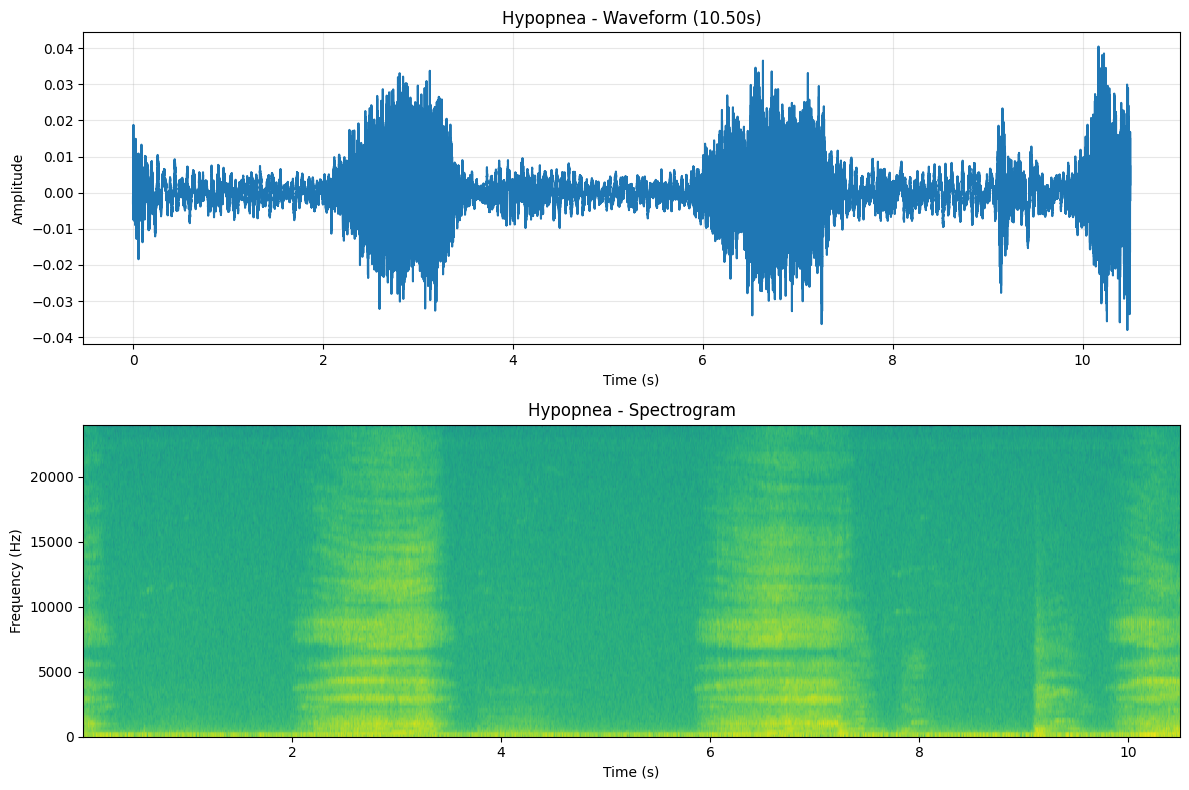

📈 Stats: mean=0.0036, max=0.0405, RMS=0.0051
🔊 Playing audio (resampled to 16000 Hz)...



🎵 Example: MixedApnea (15.50s)
   Time: 6234.5s - 6250.0s
   ❌ Empty segment, skipping...

🎵 Example: Snore (8.00s)
   Time: 12758.0s - 12766.0s
   ❌ Empty segment, skipping...


In [16]:
# =====================
# Direct EDF Audio Exploration with file selection (Randomized Events)
# =====================
def explore_edf_audio(edf_filename=None, max_examples=3, random_state=None):
    """Explore random audio events directly from EDF file (Mic channel)."""
    
    import os
    import pandas as pd
    import pyedflib
    import numpy as np
    import matplotlib.pyplot as plt
    import IPython.display as ipd
    import random
    
    EDF_DIR = r"C:\V89\data_test\EDF"
    CSV_PATH = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"
    
    # If no filename specified, pick the first one
    if edf_filename is None:
        files = [f for f in os.listdir(EDF_DIR) if f.endswith(".edf")]
        if not files:
            print("❌ No EDF files found in directory!")
            return
        edf_filename = files[0]
    
    edf_path = os.path.join(EDF_DIR, edf_filename)
    if not os.path.exists(edf_path):
        print(f"❌ EDF file not found: {edf_path}")
        return
    
    print(f"🎵 Exploring audio from: {edf_filename}")
    
    # Load EDF file
    with pyedflib.EdfReader(edf_path) as f:
        channel_names = f.getSignalLabels()
        mic_idx = next((i for i, name in enumerate(channel_names) if "mic" in name.lower()), None)
        
        if mic_idx is None:
            print("❌ No Mic channel found!")
            return
        
        print(f"✅ Found Mic channel: {channel_names[mic_idx]}")
        sr = f.getSampleFrequency(mic_idx)
        mic_signal = f.readSignal(mic_idx)
    
    duration_total = len(mic_signal) / sr
    print(f"🔊 Sampling rate: {sr} Hz | Total duration: {duration_total:.2f}s")
    
    # Load CSV events
    df = pd.read_csv(CSV_PATH)
    patient_id = int(edf_filename.split('-')[0])
    df_patient = df[df['patient_id'] == patient_id].copy()
    
    if df_patient.empty:
        print("❌ No events found for this patient!")
        return
    
    print(f"\n📊 Found {len(df_patient)} events for patient {patient_id}")
    
    # Group events by type
    event_groups = df_patient.groupby('type')
    
    print("\n🎯 Event types and counts:")
    for event_type, group in event_groups:
        print(f"  {event_type}: {len(group)} events")
    
    # Random examples
    rng = np.random.default_rng(random_state)
    examples_shown = 0
    
    for event_type, group in event_groups:
        if examples_shown >= max_examples:
            break
        
        # random row instead of first row
        row = group.sample(1, random_state=rng).iloc[0]
        
        start_sec, end_sec = float(row['start_sec']), float(row['end_sec'])
        duration = end_sec - start_sec
        
        print(f"\n🎵 Example: {event_type} ({duration:.2f}s)")
        print(f"   Time: {start_sec:.1f}s - {end_sec:.1f}s")
        
        # Cut signal
        start_sample = int(start_sec * sr)
        end_sample = min(int(end_sec * sr), len(mic_signal))
        segment = mic_signal[start_sample:end_sample]
        
        if segment.size == 0:
            print("   ❌ Empty segment, skipping...")
            continue
        
        segment_duration = len(segment) / sr
        time = np.linspace(0, segment_duration, len(segment))
        
        # Plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        ax1.plot(time, segment)
        ax1.set_title(f'{event_type} - Waveform ({segment_duration:.2f}s)')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Amplitude')
        ax1.grid(True, alpha=0.3)
        
        ax2.specgram(segment, Fs=sr, cmap='viridis')
        ax2.set_title(f'{event_type} - Spectrogram')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Frequency (Hz)')
        
        plt.tight_layout()
        plt.show()
        
        # Stats
        print(f"📈 Stats: mean={np.mean(np.abs(segment)):.4f}, "
              f"max={np.max(np.abs(segment)):.4f}, "
              f"RMS={np.sqrt(np.mean(segment**2)):.4f}")
        
        # Play audio
        if sr > 16000:
            factor = int(sr // 16000)
            factor = max(1, factor)
            segment_16k = segment[::factor]
            sr_play = int(sr // factor)
        else:
            segment_16k = segment
            sr_play = int(sr)

        print(f"🔊 Playing audio (resampled to {sr_play} Hz)...")
        display(ipd.Audio(segment_16k, rate=sr_play))

        
        examples_shown += 1
        print("="*60)


# Run exploration
print("🚀 Starting randomized EDF audio exploration...")
explore_edf_audio(max_examples=5)  # เปลี่ยนจำนวนตัวอย่างได้


In [22]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyedflib

def explore_all_classes(edf_path, csv_path, patient_id, max_per_class=1):
    """
    Compare Snore vs Apnea (all types) + Hypopnea by showing
    waveform and spectrogram from Mic channel.
    
    Parameters
    ----------
    edf_path : str
        Path to EDF file.
    csv_path : str
        Path to CSV annotations.
    patient_id : int
        Patient ID for filtering events in CSV.
    max_per_class : int
        How many random examples per class to show.
    """
    # Load CSV
    df = pd.read_csv(csv_path)
    df_patient = df[df["patient_id"] == patient_id]

    if len(df_patient) == 0:
        print(f"❌ No events for patient {patient_id}")
        return
    
    print(f"📊 Found {len(df_patient)} events for patient {patient_id}")

    # Open EDF
    with pyedflib.EdfReader(edf_path) as f:
        channels = f.getSignalLabels()
        mic_idx = next(i for i, ch in enumerate(channels) if "mic" in ch.lower())
        sr = f.getSampleFrequency(mic_idx)
        mic_signal = f.readSignal(mic_idx)

    # Group by class
    for event_type, group in df_patient.groupby("type"):
        print(f"\n🎯 Class: {event_type} ({len(group)} events)")
        # Randomly pick examples
        n_show = min(max_per_class, len(group))
        chosen = group.sample(n_show, random_state=random.randint(0,9999))
        
        for _, row in chosen.iterrows():
            start, end = int(row["start_sec"]*sr), int(row["end_sec"]*sr)
            segment = mic_signal[start:end]
            
            if len(segment) == 0:
                print("⚠️ Empty segment, skipping...")
                continue
            
            time = np.linspace(0, len(segment)/sr, len(segment))

            # Plot waveform + spectrogram
            fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,6))
            ax1.plot(time, segment)
            ax1.set_title(f"{event_type} - Waveform ({row['start_sec']:.1f}s - {row['end_sec']:.1f}s)")
            ax1.set_xlabel("Time (s)")
            ax1.set_ylabel("Amplitude")

            ax2.specgram(segment, Fs=sr, cmap="viridis")
            ax2.set_title(f"{event_type} - Spectrogram")
            ax2.set_xlabel("Time (s)")
            ax2.set_ylabel("Frequency (Hz)")

            plt.tight_layout()
            plt.show()


In [24]:
df = pd.read_csv(r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv")
df

,patient_id,event_id,family,type,start_sec,duration_sec,end_sec,segment_index,segment_local_start_sec,recording_start_iso
0,1010,3,Nasal,Snore,40.0,6.0,46.0,0,40.0,2019-05-03T23:06:21
1,1010,5,Nasal,Snore,57.5,17.0,74.5,0,57.5,2019-05-03T23:06:21
2,1010,12,Nasal,Snore,91.5,11.5,103.0,0,91.5,2019-05-03T23:06:21
3,1010,36,Respiratory,Hypopnea,865.0,12.0,877.0,0,865.0,2019-05-03T23:06:21
4,1010,44,Respiratory,Hypopnea,1075.0,10.0,1085.0,0,1075.0,2019-05-03T23:06:21
...,...,...,...,...,...,...,...,...,...,...
590,1016,779,Respiratory,Hypopnea,20655.5,15.0,20670.5,5,2655.5,2019-05-08T23:04:32
591,1016,784,Respiratory,Hypopnea,20724.5,12.5,20737.0,5,2724.5,2019-05-08T23:04:32
592,1016,796,Respiratory,Hypopnea,21414.5,10.0,21424.5,5,3414.5,2019-05-08T23:04:32
593,1016,799,Respiratory,MixedApnea,21434.5,13.5,21448.0,5,3434.5,2019-05-08T23:04:32


In [30]:
# ดู type ของ family "Respiratory"
respiratory_types = df[df['family'] == 'Respiratory']['type'].value_counts()
print("Types in Respiratory family:")
print(respiratory_types)

# ดู type ของ family "Nasal" 
nasal_types = df[df['family'] == 'Nasal']['type'].value_counts()
print("\nTypes in Nasal family:")
print(nasal_types)

Types in Respiratory family:
type
Hypopnea        155
MixedApnea       21
CentralApnea      4
Name: count, dtype: int64

Types in Nasal family:
type
Snore    415
Name: count, dtype: int64


📊 Found 219 events for patient 1010

🎯 Class: CentralApnea (2 events)
⚠️ Empty segment, skipping...
⚠️ Empty segment, skipping...

🎯 Class: Hypopnea (26 events)
⚠️ Empty segment, skipping...

🎯 Class: CentralApnea (2 events)
⚠️ Empty segment, skipping...
⚠️ Empty segment, skipping...

🎯 Class: Hypopnea (26 events)
⚠️ Empty segment, skipping...


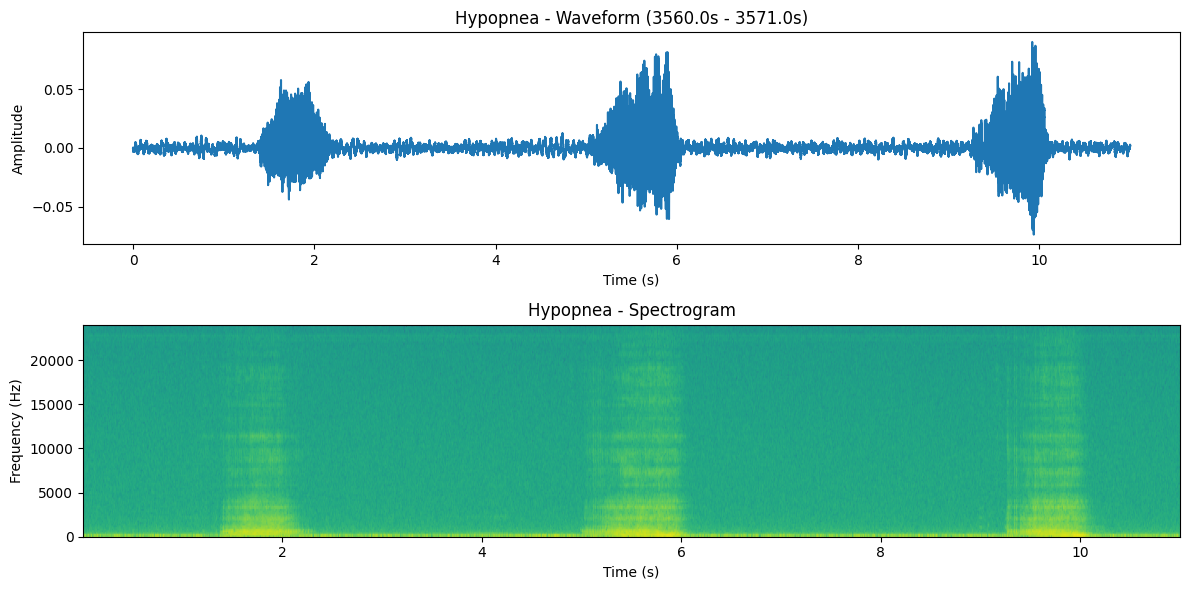


🎯 Class: MixedApnea (5 events)
⚠️ Empty segment, skipping...
⚠️ Empty segment, skipping...

🎯 Class: Snore (186 events)
⚠️ Empty segment, skipping...
⚠️ Empty segment, skipping...


In [23]:
EDF_DIR = r"C:\V89\data_test\EDF"
CSV_PATH = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"

edf_file = "00001010-100507[001].edf"   # หรือไฟล์ไหนก็ได้
patient_id = int(edf_file.split("-")[0])

explore_all_classes(os.path.join(EDF_DIR, edf_file), CSV_PATH, patient_id, max_per_class=2)

# Visualize Mic & Snore

In [21]:
import random

def explore_all_classes(edf_path, csv_path, patient_id, duration=10):
    import pyedflib, pandas as pd, numpy as np, matplotlib.pyplot as plt
    
    # โหลด CSV
    df = pd.read_csv(csv_path)
    df_patient = df[df["patient_id"] == patient_id]
    
    # เปิด EDF
    with pyedflib.EdfReader(edf_path) as f:
        channels = f.getSignalLabels()
        mic_idx = next(i for i, ch in enumerate(channels) if "mic" in ch.lower())
        sr = f.getSampleFrequency(mic_idx)
        mic_signal = f.readSignal(mic_idx)
    
    # วนทุก class
    for event_type, group in df_patient.groupby("type"):
        row = group.sample(1).iloc[0]   # สุ่มเลือก event 1 อัน
        start, end = int(row["start_sec"]*sr), int(row["end_sec"]*sr)
        
        segment = mic_signal[start:end]
        time = np.linspace(0, len(segment)/sr, len(segment))
        
        # Plot waveform + spectrogram
        fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,6))
        ax1.plot(time, segment)
        ax1.set_title(f"{event_type} - Waveform")
        ax2.specgram(segment, Fs=sr, cmap="viridis")
        ax2.set_title(f"{event_type} - Spectrogram")
        plt.tight_layout()
        plt.show()


Channels: ['EEG A1-A2', 'EEG C3-A2', 'EEG C4-A1', 'EOG LOC-A2', 'EOG ROC-A2', 'EMG Chin', 'Leg 1', 'Leg 2', 'ECG I', 'RR', 'Snore', 'Flow Patient', 'Flow Patient', 'Effort THO', 'Effort ABD', 'SpO2', 'Body', 'PulseRate', 'Mic', 'Tracheal']


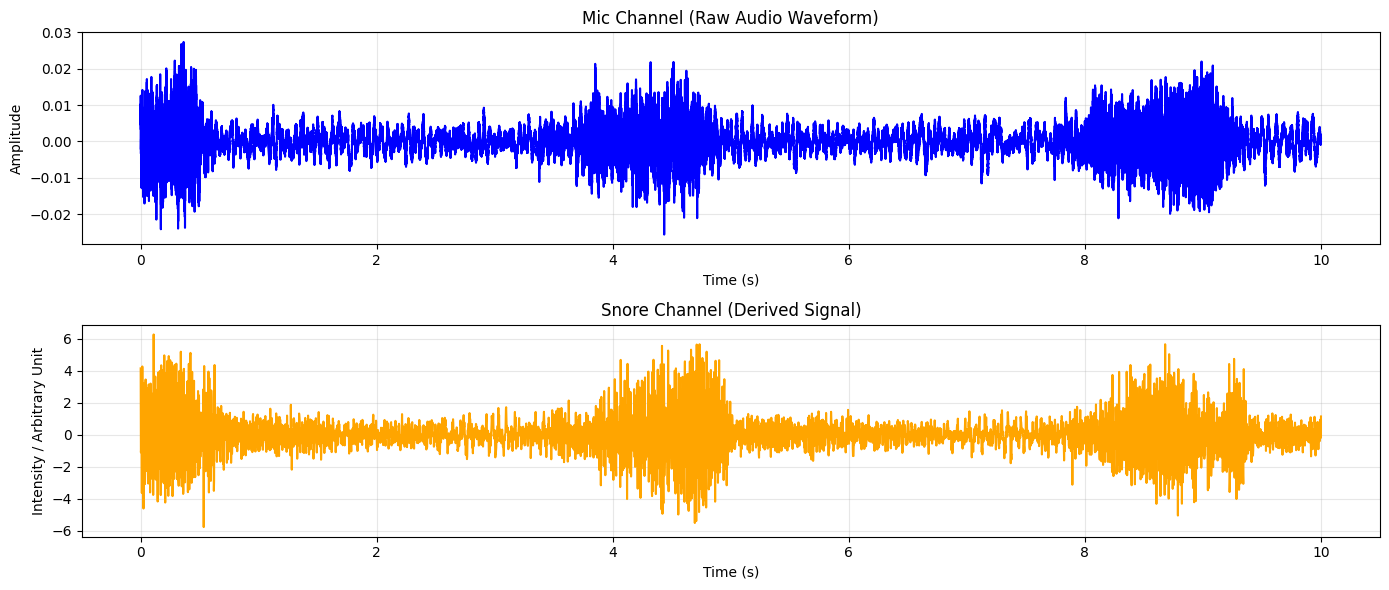

In [20]:
import os
import pyedflib
import numpy as np
import matplotlib.pyplot as plt

# ========================
# Compare Mic vs Snore channel
# ========================
EDF_PATH = r"C:\V89\data_test\EDF\00001010-100507[001].edf"

# เลือกช่วงเวลาที่อยากดู (วินาที)
start_sec = 2455   # ตัวอย่างจาก event Snore
duration_sec = 10  # แสดง 10 วินาที

with pyedflib.EdfReader(EDF_PATH) as f:
    channels = f.getSignalLabels()
    print("Channels:", channels)

    # หา index ของ Mic และ Snore
    mic_idx = next((i for i, ch in enumerate(channels) if "mic" in ch.lower()), None)
    snore_idx = next((i for i, ch in enumerate(channels) if "snore" in ch.lower()), None)

    if mic_idx is None or snore_idx is None:
        raise ValueError("❌ ไม่เจอ Mic หรือ Snore channel ใน EDF")

    # Sampling rate
    sr_mic = f.getSampleFrequency(mic_idx)
    sr_snore = f.getSampleFrequency(snore_idx)

    # ดึงช่วงสัญญาณ
    start_sample_mic = int(start_sec * sr_mic)
    end_sample_mic   = int((start_sec + duration_sec) * sr_mic)

    start_sample_snore = int(start_sec * sr_snore)
    end_sample_snore   = int((start_sec + duration_sec) * sr_snore)

    mic_signal   = f.readSignal(mic_idx)[start_sample_mic:end_sample_mic]
    snore_signal = f.readSignal(snore_idx)[start_sample_snore:end_sample_snore]

# ========================
# Plot เทียบกัน
# ========================
time_mic = np.linspace(0, duration_sec, len(mic_signal))
time_snore = np.linspace(0, duration_sec, len(snore_signal))

plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(time_mic, mic_signal, color='blue')
plt.title("Mic Channel (Raw Audio Waveform)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
plt.plot(time_snore, snore_signal, color='orange')
plt.title("Snore Channel (Derived Signal)")
plt.xlabel("Time (s)")
plt.ylabel("Intensity / Arbitrary Unit")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Non-Hypopnea Events:
Total events: 440

Event types available:
type
Snore           415
MixedApnea       21
CentralApnea      4
Name: count, dtype: int64

🎯 Selected Event:
Type: Snore
Family: Nasal
Start: 57.5s
Duration: 17.0s

Channels available: ['EEG A1-A2', 'EEG C3-A2', 'EEG C4-A1', 'EOG LOC-A2', 'EOG ROC-A2', 'EMG Chin', 'Leg 1', 'Leg 2', 'ECG I', 'RR', 'Snore', 'Flow Patient', 'Flow Patient', 'Effort THO', 'Effort ABD', 'SpO2', 'Body', 'PulseRate', 'Mic', 'Tracheal']
✅ Found Mic channel: Mic (index: 18)
✅ Found Snore channel: Snore (index: 10)
Mic sampling rate: 48000.0 Hz
Snore sampling rate: 500.0 Hz


C:\Users\Abcde\AppData\Local\Temp\ipykernel_14760\4090910149.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Abcde\AppData\Local\Temp\ipykernel_14760\4090910149.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


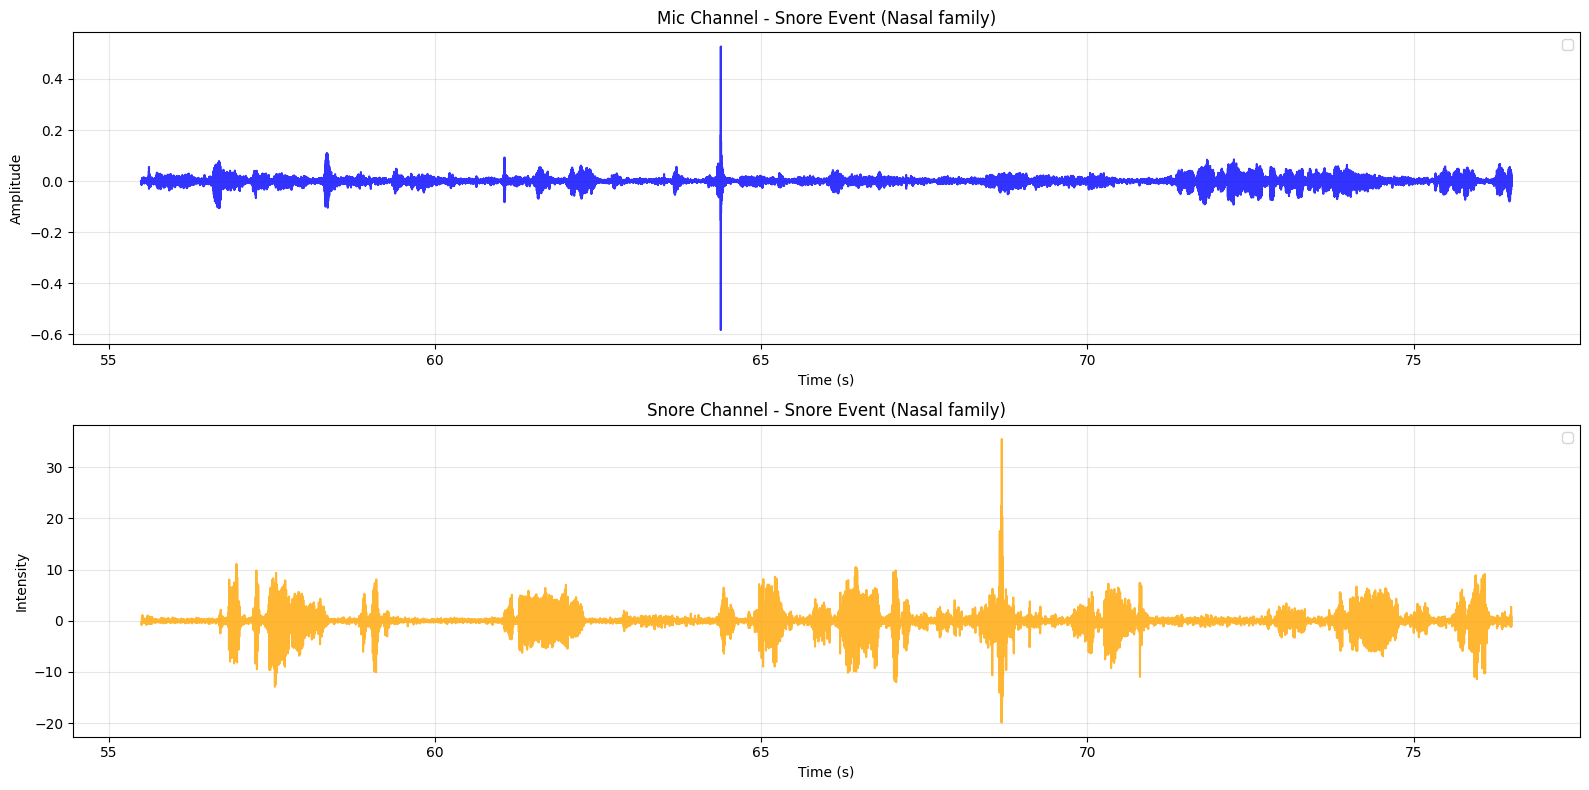


🔊 Playing audio from Mic channel...
Duration: 21.0 seconds
Sample rate: 48000.0 Hz
▶️ Playing audio... (Press Ctrl+C to stop)
✅ Audio playback completed

📊 Audio Analysis:
Signal length: 1008000 samples
Duration: 21.00 seconds
Max amplitude: 0.5840
RMS amplitude: 0.0113
Dominant frequency: 23.3 Hz
✅ Audio playback completed

📊 Audio Analysis:
Signal length: 1008000 samples
Duration: 21.00 seconds
Max amplitude: 0.5840
RMS amplitude: 0.0113
Dominant frequency: 23.3 Hz


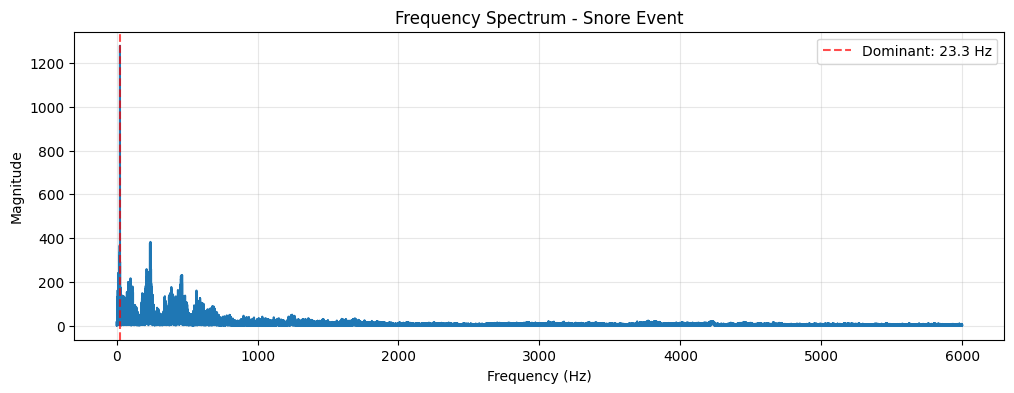


📋 Other Non-Hypopnea Events (first 5):
0: Snore (Nasal) - Start: 40.0s, Duration: 6.0s
1: Snore (Nasal) - Start: 57.5s, Duration: 17.0s
2: Snore (Nasal) - Start: 91.5s, Duration: 11.5s
10: MixedApnea (Respiratory) - Start: 1612.5s, Duration: 20.5s
11: Snore (Nasal) - Start: 2302.5s, Duration: 3.5s

💡 หากต้องการดู event อื่น ให้เปลี่ยน selected_event = non_hypopnea_events.iloc[INDEX]


In [42]:
import os
import pandas as pd
import pyedflib
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io import wavfile
import tempfile

# ========================
# Load CSV และหา events ที่ไม่ใช่ Hypopnea
# ========================
CSV_PATH = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"
EDF_PATH = r"C:\V89\data_test\EDF\00001010-100507[001].edf"

# อ่าน CSV
df = pd.read_csv(CSV_PATH)

# กรองเฉพาะ events ที่ไม่ใช่ Hypopnea
non_hypopnea_events = df[df['type'] != 'Hypopnea'].copy()
print("Non-Hypopnea Events:")
print(f"Total events: {len(non_hypopnea_events)}")
print("\nEvent types available:")
print(non_hypopnea_events['type'].value_counts())

if len(non_hypopnea_events) == 0:
    print("❌ ไม่มี event ที่ไม่ใช่ Hypopnea!")
    exit()

# เลือก event แรกที่ไม่ใช่ Hypopnea
selected_event = non_hypopnea_events.iloc[1]
start_sec = selected_event['start_sec']
duration_sec = selected_event['duration_sec']
event_type = selected_event['type']
family = selected_event['family']

print(f"\n🎯 Selected Event:")
print(f"Type: {event_type}")
print(f"Family: {family}")
print(f"Start: {start_sec:.1f}s")
print(f"Duration: {duration_sec:.1f}s")

# ========================
# เปิด EDF และดึงสัญญาณ
# ========================
with pyedflib.EdfReader(EDF_PATH) as f:
    channels = f.getSignalLabels()
    print(f"\nChannels available: {channels}")

    # หา index ของ Mic และ Snore
    mic_idx = next((i for i, ch in enumerate(channels) if "mic" in ch.lower()), None)
    snore_idx = next((i for i, ch in enumerate(channels) if "snore" in ch.lower()), None)

    if mic_idx is None or snore_idx is None:
        print("❌ ไม่เจอ Mic หรือ Snore channel ใน EDF")
        print(f"Available channels: {channels}")
        exit()

    print(f"✅ Found Mic channel: {channels[mic_idx]} (index: {mic_idx})")
    print(f"✅ Found Snore channel: {channels[snore_idx]} (index: {snore_idx})")

    # Sampling rate
    sr_mic = f.getSampleFrequency(mic_idx)
    sr_snore = f.getSampleFrequency(snore_idx)
    
    print(f"Mic sampling rate: {sr_mic} Hz")
    print(f"Snore sampling rate: {sr_snore} Hz")

    # เพิ่มช่วงเวลาให้ดูได้ชัดขึ้น (ก่อนหน้า 2 วินาที หลังจบ 2 วินาที)
    buffer_sec = 2
    plot_start_sec = max(0, start_sec - buffer_sec)
    plot_duration_sec = duration_sec + (2 * buffer_sec)
    
    # ดึงช่วงสัญญาณ
    start_sample_mic = int(plot_start_sec * sr_mic)
    end_sample_mic   = int((plot_start_sec + plot_duration_sec) * sr_mic)

    start_sample_snore = int(plot_start_sec * sr_snore)
    end_sample_snore   = int((plot_start_sec + plot_duration_sec) * sr_snore)

    # อ่านสัญญาณ
    try:
        mic_signal   = f.readSignal(mic_idx)[start_sample_mic:end_sample_mic]
        snore_signal = f.readSignal(snore_idx)[start_sample_snore:end_sample_snore]
    except Exception as e:
        print(f"❌ Error reading signal: {e}")
        exit()

# ========================
# Plot เทียบกัน
# ========================
time_mic = np.linspace(0, plot_duration_sec, len(mic_signal)) + plot_start_sec
time_snore = np.linspace(0, plot_duration_sec, len(snore_signal)) + plot_start_sec

plt.figure(figsize=(16, 8))

plt.subplot(2,1,1)
plt.plot(time_mic, mic_signal, color='blue', alpha=0.8)
plt.title(f"Mic Channel - {event_type} Event ({family} family)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2,1,2)
plt.plot(time_snore, snore_signal, color='orange', alpha=0.8)
plt.title(f"Snore Channel - {event_type} Event ({family} family)")
plt.xlabel("Time (s)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ========================
# เล่นเสียงจาก Mic channel
# ========================
print(f"\n🔊 Playing audio from Mic channel...")
print(f"Duration: {plot_duration_sec:.1f} seconds")
print(f"Sample rate: {sr_mic} Hz")

# ปรับระดับเสียงให้เหมาะสม (normalize)
mic_normalized = mic_signal / np.max(np.abs(mic_signal)) * 0.5  # ลดระดับเสียงป้องกันเสียงดังเกินไป

try:
    # วิธีที่ 1: ใช้ sounddevice เล่นโดยตรง
    print("▶️ Playing audio... (Press Ctrl+C to stop)")
    sd.play(mic_normalized, samplerate=int(sr_mic))
    sd.wait()  # รอให้เล่นจบ
    print("✅ Audio playback completed")
    
except ImportError:
    print("❌ sounddevice not installed. Trying to save as WAV file...")
    # วิธีที่ 2: บันทึกเป็นไฟล์ WAV แทน
    try:
        # สร้างไฟล์ temp
        temp_dir = tempfile.gettempdir()
        wav_path = os.path.join(temp_dir, f"mic_audio_{event_type}_{start_sec:.0f}s.wav")
        
        # แปลงเป็น 16-bit PCM
        mic_int16 = (mic_normalized * 32767).astype(np.int16)
        wavfile.write(wav_path, int(sr_mic), mic_int16)
        
        print(f"💾 Audio saved to: {wav_path}")
        print("🎵 You can play this file with any audio player")
        
    except Exception as e:
        print(f"❌ Error saving audio: {e}")
        
except Exception as e:
    print(f"❌ Error playing audio: {e}")

# ========================
# แสดงข้อมูลเพิ่มเติมเกี่ยวกับเสียง
# ========================
print(f"\n📊 Audio Analysis:")
print(f"Signal length: {len(mic_signal)} samples")
print(f"Duration: {len(mic_signal)/sr_mic:.2f} seconds")
print(f"Max amplitude: {np.max(np.abs(mic_signal)):.4f}")
print(f"RMS amplitude: {np.sqrt(np.mean(mic_signal**2)):.4f}")

# คำนวณ frequency spectrum (FFT)
fft = np.fft.rfft(mic_signal)
freqs = np.fft.rfftfreq(len(mic_signal), 1/sr_mic)
magnitude = np.abs(fft)

# หา dominant frequency
dominant_freq_idx = np.argmax(magnitude[1:]) + 1  # skip DC component
dominant_freq = freqs[dominant_freq_idx]
print(f"Dominant frequency: {dominant_freq:.1f} Hz")

# Plot frequency spectrum
plt.figure(figsize=(12, 4))
plt.plot(freqs[:len(freqs)//4], magnitude[:len(magnitude)//4])  # แสดงแค่ 1/4 แรก
plt.axvline(dominant_freq, color='red', linestyle='--', alpha=0.7, label=f'Dominant: {dominant_freq:.1f} Hz')
plt.title(f"Frequency Spectrum - {event_type} Event")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ========================
# แสดงรายการ events อื่นๆ ที่ไม่ใช่ Hypopnea (optional)
# ========================
print(f"\n📋 Other Non-Hypopnea Events (first 5):")
for idx, row in non_hypopnea_events.head().iterrows():
    print(f"{idx}: {row['type']} ({row['family']}) - Start: {row['start_sec']:.1f}s, Duration: {row['duration_sec']:.1f}s")

# ถ้าต้องการดู event อื่น ให้เปลี่ยน index ที่นี่
print(f"\n💡 หากต้องการดู event อื่น ให้เปลี่ยน selected_event = non_hypopnea_events.iloc[INDEX]")

In [47]:
SAVE_DIR = r"C:\V89\plots"
os.makedirs(SAVE_DIR, exist_ok=True)

# ใช้แค่ 3 events แรก
for i, (_, row) in enumerate(df_patient.head(3).iterrows(), 1):
    start, end = int(row['start_sec']), int(row['end_sec'])
    event_type = row['type']
    family = row['family']
    duration = row['duration_sec']
    
    print(f"🎯 Processing Event {i}: {event_type} ({family}) - {start}s to {end}s ({duration:.1f}s)")

    # ตัดสัญญาณ
    seg_snore = sig_snore[start*int(sr_snore):end*int(sr_snore)]
    seg_mic   = sig_mic[start*int(sr_mic):end*int(sr_mic)]

    time_snore = np.linspace(0, len(seg_snore)/sr_snore, len(seg_snore))
    time_mic   = np.linspace(0, len(seg_mic)/sr_mic, len(seg_mic))

    plt.figure(figsize=(14,10))
    
    # เพิ่ม suptitle แสดงข้อมูล event
    plt.suptitle(f'Event {i}: {event_type} ({family} family) - {start}s-{end}s ({duration:.1f}s)', 
                 fontsize=16, fontweight='bold', y=0.98)

    # Mic waveform
    plt.subplot(2,2,1)
    plt.plot(time_mic, seg_mic, color='blue')
    plt.title(f"Mic Channel - Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.ylim([-0.2, 0.2])
    plt.grid(alpha=0.3)

    # Mic spectrogram
    f, t, Sxx = spectrogram(seg_mic, sr_mic, nperseg=256, noverlap=128)
    plt.subplot(2,2,2)
    plt.pcolormesh(t, f, 10*np.log10(Sxx+1e-10), shading='gouraud', cmap='viridis')
    plt.title("Mic Channel - Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="dB")

    # Snore waveform
    plt.subplot(2,2,3)
    plt.plot(time_snore, seg_snore, color='orange')
    plt.title(f"Snore Channel - Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Intensity")
    plt.ylim([-20, 20])
    plt.grid(alpha=0.3)

    # Snore spectrogram
    f, t, Sxx = spectrogram(seg_snore, sr_snore, nperseg=256, noverlap=128)
    plt.subplot(2,2,4)
    plt.pcolormesh(t, f, 10*np.log10(Sxx+1e-10), shading='gouraud', cmap='inferno')
    plt.title("Snore Channel - Spectrogram")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="dB")

    plt.tight_layout()

    # Save figure พร้อมชื่อไฟล์ที่บอกชนิด event
    filename = f"event_{i}_{event_type}_{family}_{start}s-{end}s.png"
    save_path = os.path.join(SAVE_DIR, filename)
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close()

    print(f"✅ Saved: {filename}")

print(f"\n📁 All plots saved to: {SAVE_DIR}")

🎯 Processing Event 1: Snore (Nasal) - 40s to 46s (6.0s)
✅ Saved: event_1_Snore_Nasal_40s-46s.png
🎯 Processing Event 2: Snore (Nasal) - 57s to 74s (17.0s)
✅ Saved: event_1_Snore_Nasal_40s-46s.png
🎯 Processing Event 2: Snore (Nasal) - 57s to 74s (17.0s)
✅ Saved: event_2_Snore_Nasal_57s-74s.png
🎯 Processing Event 3: Snore (Nasal) - 91s to 103s (11.5s)
✅ Saved: event_2_Snore_Nasal_57s-74s.png
🎯 Processing Event 3: Snore (Nasal) - 91s to 103s (11.5s)
✅ Saved: event_3_Snore_Nasal_91s-103s.png

📁 All plots saved to: C:\V89\plots
✅ Saved: event_3_Snore_Nasal_91s-103s.png

📁 All plots saved to: C:\V89\plots
